# LeetCode #243: Shortest Word Distance

https://leetcode.com/problems/shortest-word-distance/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **One-Pass Linear Scan** ★ | $O(n)$ | $O(1)$ |

---

## Understanding the Methods

### Brute Force
For each occurrence of word1 at index i, scan for every occurrence of word2 at index j and record |i − j|. Checking all pairs is $O(n^2)$ — redundant because once we pass an index, only the most recent occurrence of each word can minimize future distances.

### Optimal: One-Pass Linear Scan ★
Track the most recent index seen for each word (i1 and i2). Whenever either word is encountered, update its index and immediately compute the distance to the other word's last known index. The closest pair is always formed by the two most recently seen positions.

**Why this is better than Brute Force:** Old occurrences of word1 can never beat a newer one when paired with the same word2 position — the newer index is always closer. Tracking only the latest index per word eliminates the inner loop entirely: $O(n^2) \to O(n)$.

**Constraints:**
* 2 ≤ wordsDict.length ≤ 3 × 10⁴
* word1 and word2 are in wordsDict
* word1 ≠ word2

## Solutions

### C#

In [ ]:
public class Solution {
    public int ShortestDistance(string[] wordsDict, string word1, string word2) {
        int i1 = -1, i2 = -1, minDist = int.MaxValue;
        for (int i = 0; i < wordsDict.Length; i++) {
            if      (wordsDict[i] == word1) i1 = i;
            else if (wordsDict[i] == word2) i2 = i;
            // Update best whenever both words have been seen at least once
            if (i1 != -1 && i2 != -1)
                minDist = Math.Min(minDist, Math.Abs(i1 - i2));
        }
        return minDist;
    }
}

### Python

In [ ]:
class Solution:
    def shortestDistance(self, wordsDict: List[str], word1: str, word2: str) -> int:
        i1, i2, min_dist = -1, -1, float('inf')
        for i, word in enumerate(wordsDict):
            if   word == word1: i1 = i
            elif word == word2: i2 = i
            # Update best whenever both words have been seen at least once
            if i1 != -1 and i2 != -1:
                min_dist = min(min_dist, abs(i1 - i2))
        return min_dist

### Go

In [ ]:
import "math"

func shortestDistance(wordsDict []string, word1 string, word2 string) int {
    i1, i2, minDist := -1, -1, math.MaxInt32
    for i, word := range wordsDict {
        if word == word1 {
            i1 = i
        } else if word == word2 {
            i2 = i
        }
        // Update best whenever both words have been seen at least once
        if i1 != -1 && i2 != -1 {
            if d := i1 - i2; d < 0 {
                if -d < minDist { minDist = -d }
            } else {
                if d < minDist { minDist = d }
            }
        }
    }
    return minDist
}

### Rust

In [ ]:
pub fn shortest_distance(words_dict: Vec<String>, word1: String, word2: String) -> i32 {
    let (mut i1, mut i2, mut min_dist) = (-1i32, -1i32, i32::MAX);
    for (i, word) in words_dict.iter().enumerate() {
        if      word == &word1 { i1 = i as i32; }
        else if word == &word2 { i2 = i as i32; }
        // Update best whenever both words have been seen at least once
        if i1 != -1 && i2 != -1 {
            min_dist = min_dist.min((i1 - i2).abs());
        }
    }
    min_dist
}

## Example Scenarios

**1. Common Case**
**Input:** wordsDict = ["practice","makes","perfect","coding","makes"], word1 = "coding", word2 = "practice"
i=0: "practice" → i2=0. i=1,2: skip. i=3: "coding" → i1=3, dist=|3−0|=3. i=4: "makes" → skip. Only one distance computed. Output: **3**.

**2. Slightly Complex — later pair beats the first**
**Input:** wordsDict = ["a","b","c","b","a"], word1 = "a", word2 = "b"
i=0: i1=0. i=1: i2=1, dist=1. i=3: i2=3, dist=|0−3|=3 (no improvement). i=4: i1=4, dist=|4−3|=1. The first and last pairs both yield distance 1; the middle pair is worse. Output: **1**. The algorithm never backtracks — the running minimum absorbs ties naturally.

**3. Edge Case: Time Factor — words at opposite ends**
**Input:** wordsDict = ["a", "x", "x", …, "x", "b"] (n elements), word1 = "a", word2 = "b"
i=0: i1=0. i=1…n−2: no match, no update to i1/i2. i=n−1: i2=n−1, dist=n−1. Exactly one distance computed across n iterations. Brute Force: scans all word2 positions for every word1 occurrence → $O(n)$ pairs even here (one word1, one word2). But if word1 appears $k$ times and word2 appears $m$ times, Brute Force is $O(k \cdot m)$ while One-Pass stays $O(n)$.

**4. Edge Case: Space Factor — O(1) regardless of array size**
**Input:** n = 3 × 10⁴ elements
Only three integers are ever allocated: i1, i2, minDist. No list of indices, no hash map of word → positions. Contrast with a naive preprocessing step that collects all positions of each word first: that requires $O(n)$ extra space. Output: 2 integers persisted, rest discarded after each iteration.

**5. Almost-Impossible but Plausible — words adjacent**
**Input:** wordsDict = ["hello", "world", "safe"], word1 = "hello", word2 = "world"
i=0: i1=0. i=1: i2=1, dist=|0−1|=1. i=2: skip. No subsequent update can improve on 1 — the minimum possible distance for non-overlapping positions. Output: **1**.

## Infographic

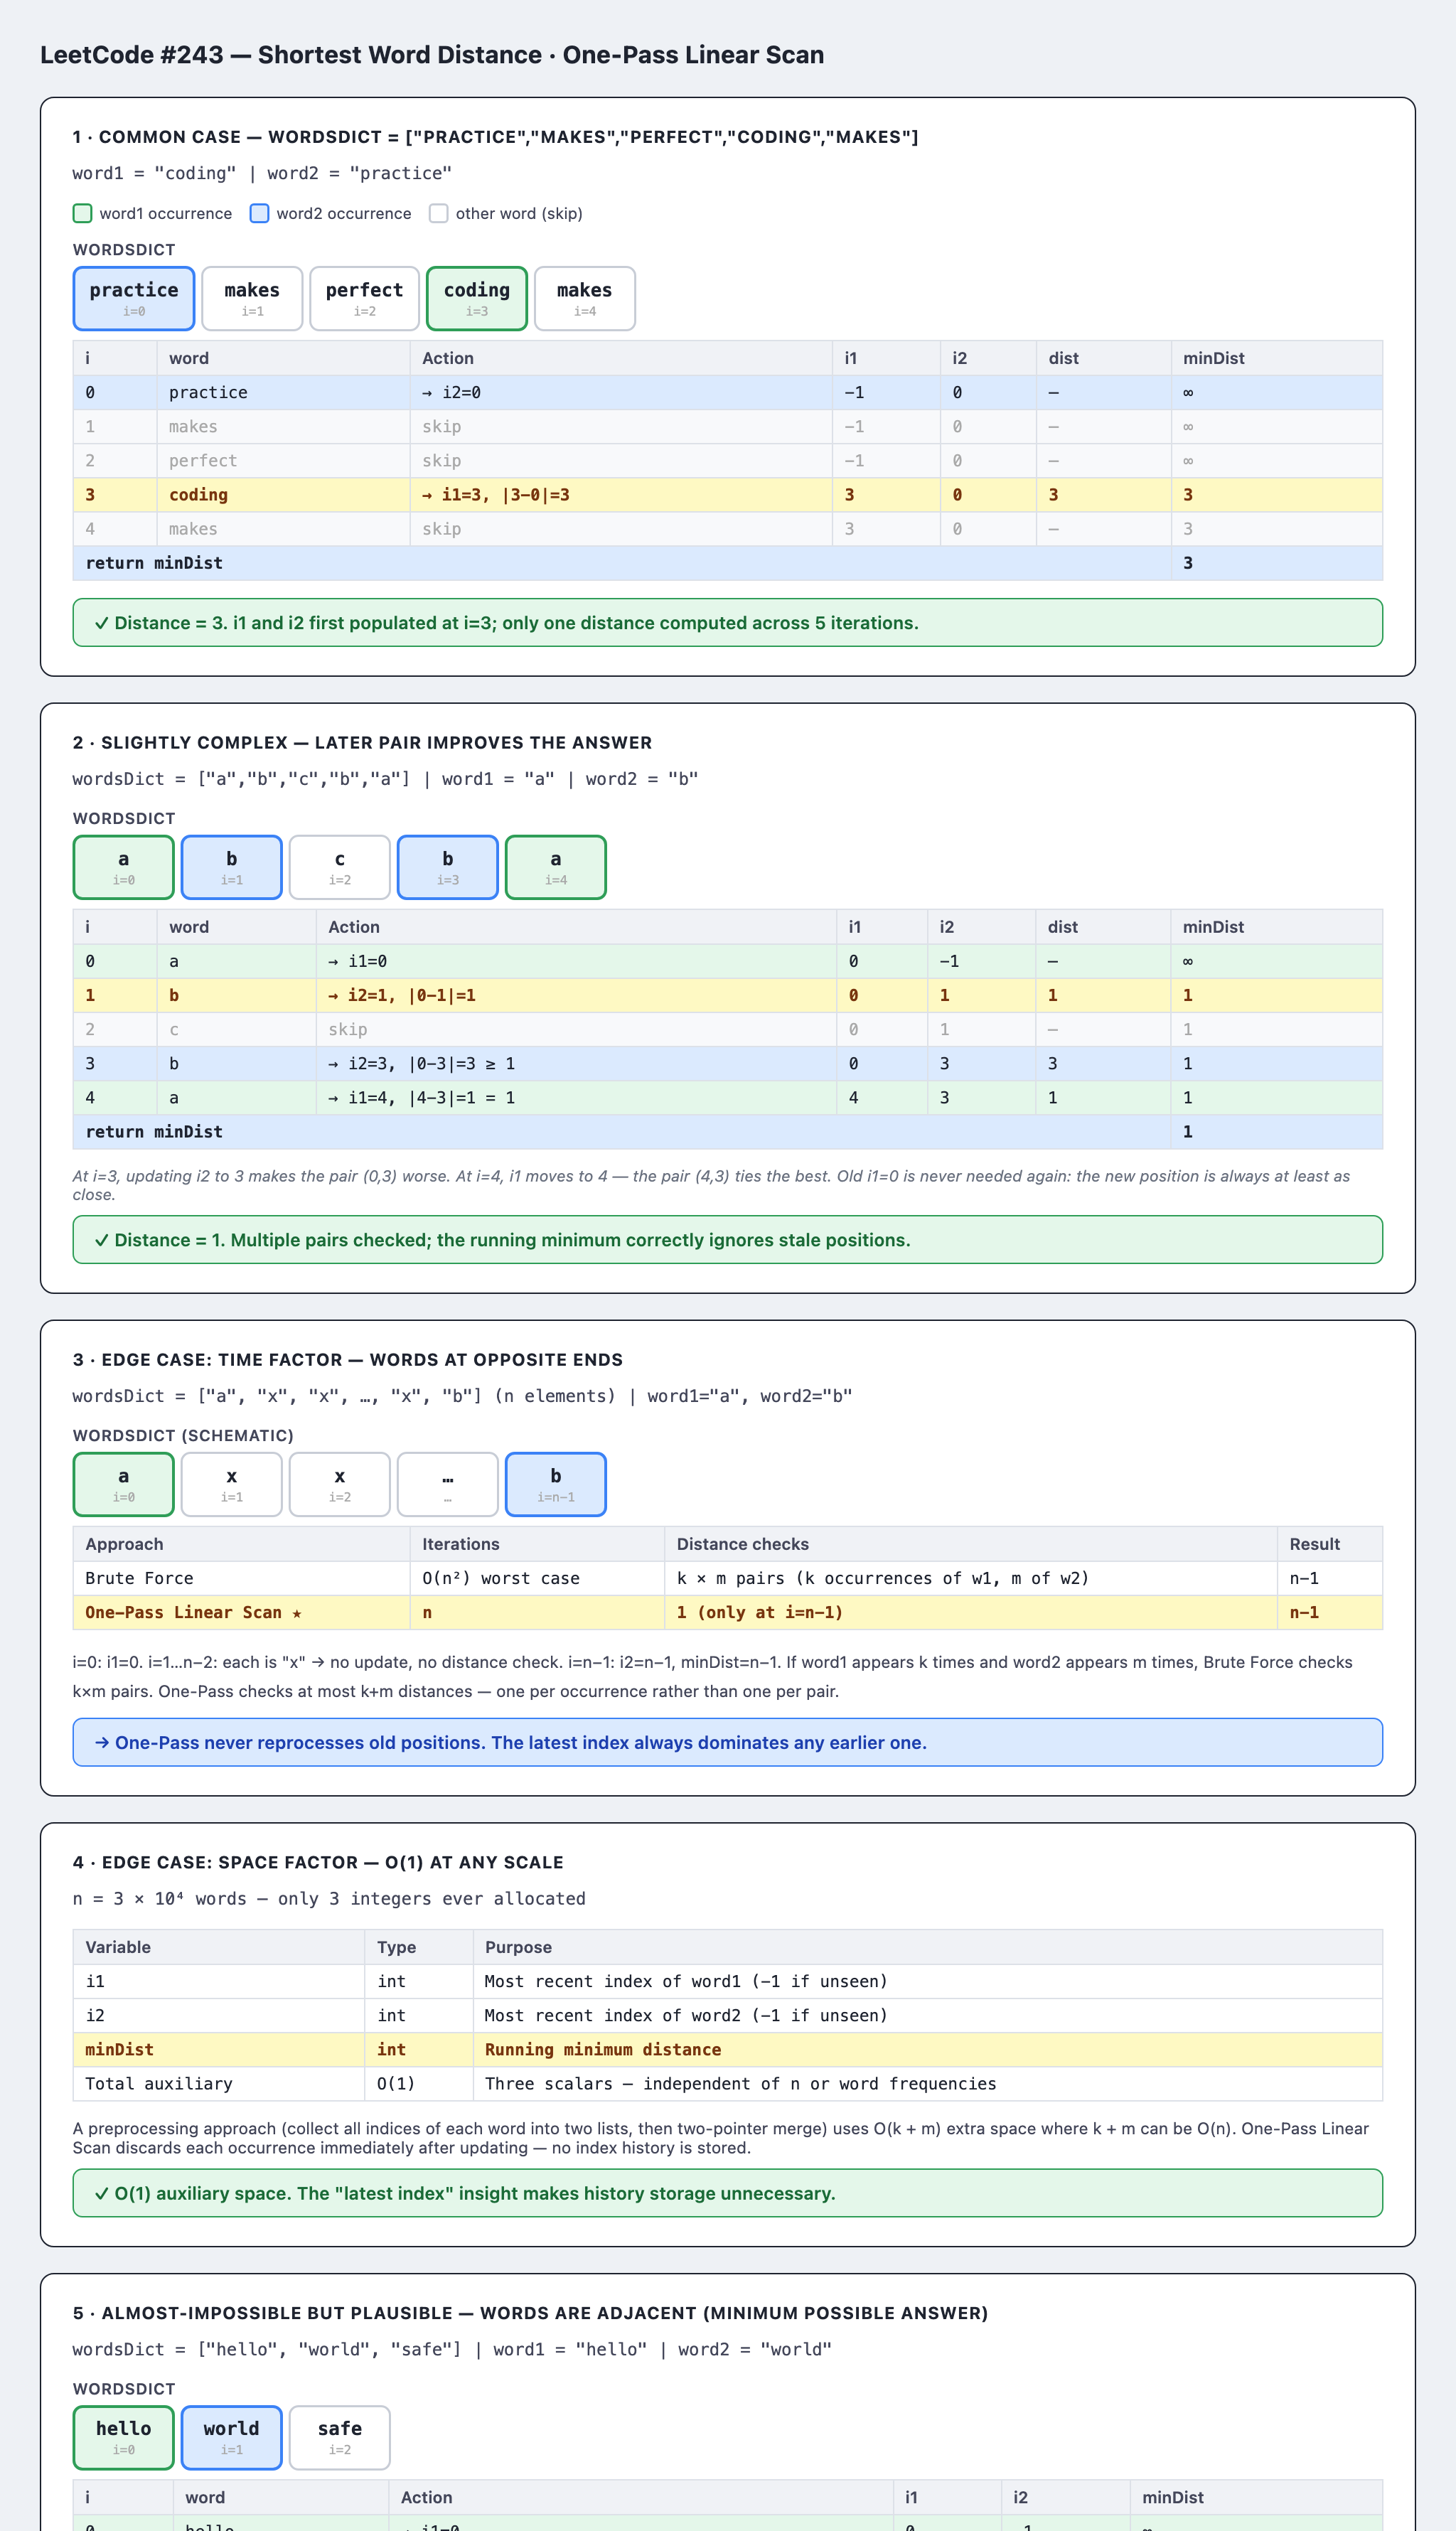